In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('burnout_dataset.csv')
df

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,20.10,Low
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,41.71,Medium
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,80.15,High
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,41.44,Medium


In [3]:
df.isnull().sum()

age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64

In [4]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.330000,4.45,2.000000,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.620000,5.77,5.000000,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,9.000277,4.03,5.000000,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.850000,6.47,2.000000,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.240000,5.80,3.540671,9.0,17.0,7.0,8.05,0.36,27.90,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
6995,25.0,14.0,6.530000,7.43,5.000000,1.0,7.0,5.0,7.55,1.67,20.10,Low
6996,30.0,19.0,10.150000,5.60,3.000000,4.0,9.0,0.0,12.11,0.96,41.71,Medium
6997,44.0,8.0,8.560000,6.80,5.000000,18.0,3.0,4.0,11.62,1.04,80.15,High
6998,25.0,2.0,4.390000,5.40,6.000000,6.0,4.0,5.0,8.24,0.82,41.44,Medium


In [5]:
df['burnout_level'] = df['burnout_level'].fillna(df['burnout_level'].mode()[0])

In [6]:
df.isnull().sum()

age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
stress_level        0
burnout_level       0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               7000 non-null   float64
 1   experience_years  7000 non-null   float64
 2   daily_work_hours  7000 non-null   float64
 3   sleep_hours       7000 non-null   float64
 4   caffeine_intake   7000 non-null   float64
 5   bugs_per_day      7000 non-null   float64
 6   commits_per_day   7000 non-null   float64
 7   meetings_per_day  7000 non-null   float64
 8   screen_time       7000 non-null   float64
 9   exercise_hours    7000 non-null   float64
 10  stress_level      7000 non-null   float64
 11  burnout_level     7000 non-null   str    
dtypes: float64(11), str(1)
memory usage: 656.4 KB


In [8]:
df['burnout_level'].value_counts()

burnout_level
Medium    3625
High      1782
Low       1593
Name: count, dtype: int64

In [9]:
df.describe()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,32.129446,9.581050,9.000277,6.485638,3.540671,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825
std,7.157576,5.703063,2.835155,1.430483,2.260492,5.693848,8.582697,2.828050,3.060131,0.570911,23.210971
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000
25%,26.000000,5.000000,6.607500,5.250000,2.000000,5.000000,7.000000,2.000000,9.520000,0.520000,36.997500
50%,32.000000,9.581050,9.000277,6.485638,4.000000,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825
75%,38.000000,15.000000,11.370000,7.710000,5.000000,14.000000,22.000000,7.000000,14.362500,1.490000,70.435000
max,44.000000,19.000000,14.000000,9.000000,7.000000,19.000000,29.000000,9.000000,18.930000,2.000000,100.000000


In [10]:
df.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.330000,4.45,2.000000,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.620000,5.77,5.000000,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,9.000277,4.03,5.000000,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.850000,6.47,2.000000,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.240000,5.80,3.540671,9.0,17.0,7.0,8.05,0.36,27.90,Low


In [11]:
df.tail()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,20.10,Low
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,41.71,Medium
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,80.15,High
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,41.44,Medium
6999,25.0,2.0,4.35,4.83,1.0,16.0,23.0,4.0,8.52,1.98,39.18,Medium


In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['burnout_level'] = le.fit_transform(df['burnout_level'])

In [13]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
from xgboost import XGBClassifier 
model_xgb = XGBClassifier()
model_xgb.fit(x_train, y_train)
y_pred_xgb = model_xgb.predict(x_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Classifier:")
print("Accuracy:", xgb_accuracy)
print(classification_report(y_test, y_pred_xgb))

XGBoost Classifier:
Accuracy: 0.9864285714285714
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       323
           1       0.97      1.00      0.98       324
           2       0.99      0.98      0.99       753

    accuracy                           0.99      1400
   macro avg       0.98      0.99      0.99      1400
weighted avg       0.99      0.99      0.99      1400



In [16]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(x_train, y_train)
y_pred_rf = model_rf.predict(x_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Classifier:")
print("Accuracy:", rf_accuracy)
print(classification_report(y_test, y_pred_rf))


Random Forest Classifier:
Accuracy: 0.9871428571428571
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       323
           1       0.99      0.98      0.98       324
           2       0.99      0.99      0.99       753

    accuracy                           0.99      1400
   macro avg       0.99      0.99      0.99      1400
weighted avg       0.99      0.99      0.99      1400



In [17]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier()
model_dt.fit(x_train, y_train)
y_pred_dt = model_dt.predict(x_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Classifier:")
print("Accuracy:", dt_accuracy)
print(classification_report(y_test, y_pred_dt))

Decision Tree Classifier:
Accuracy: 0.975
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       323
           1       0.97      0.98      0.97       324
           2       0.98      0.98      0.98       753

    accuracy                           0.97      1400
   macro avg       0.97      0.97      0.97      1400
weighted avg       0.98      0.97      0.98      1400



In [18]:
from sklearn.ensemble import GradientBoostingClassifier
model_gb = GradientBoostingClassifier()
model_gb.fit(x_train, y_train)
y_pred_gb = model_gb.predict(x_test)
gb_accuracy = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Classifier:")
print("Accuracy:", gb_accuracy)
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Classifier:
Accuracy: 0.9885714285714285
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       323
           1       0.98      0.99      0.99       324
           2       0.99      0.98      0.99       753

    accuracy                           0.99      1400
   macro avg       0.99      0.99      0.99      1400
weighted avg       0.99      0.99      0.99      1400



In [19]:
from sklearn.ensemble import AdaBoostClassifier
model_ab = AdaBoostClassifier()
model_ab.fit(x_train, y_train)
y_pred_ab = model_ab.predict(x_test)
ab_accuracy = accuracy_score(y_test, y_pred_ab)
print("AdaBoost Classifier:")
print("Accuracy:", ab_accuracy)
print(classification_report(y_test, y_pred_ab))

AdaBoost Classifier:
Accuracy: 0.9807142857142858
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.98      0.98      0.98       324
           2       0.98      0.98      0.98       753

    accuracy                           0.98      1400
   macro avg       0.98      0.98      0.98      1400
weighted avg       0.98      0.98      0.98      1400



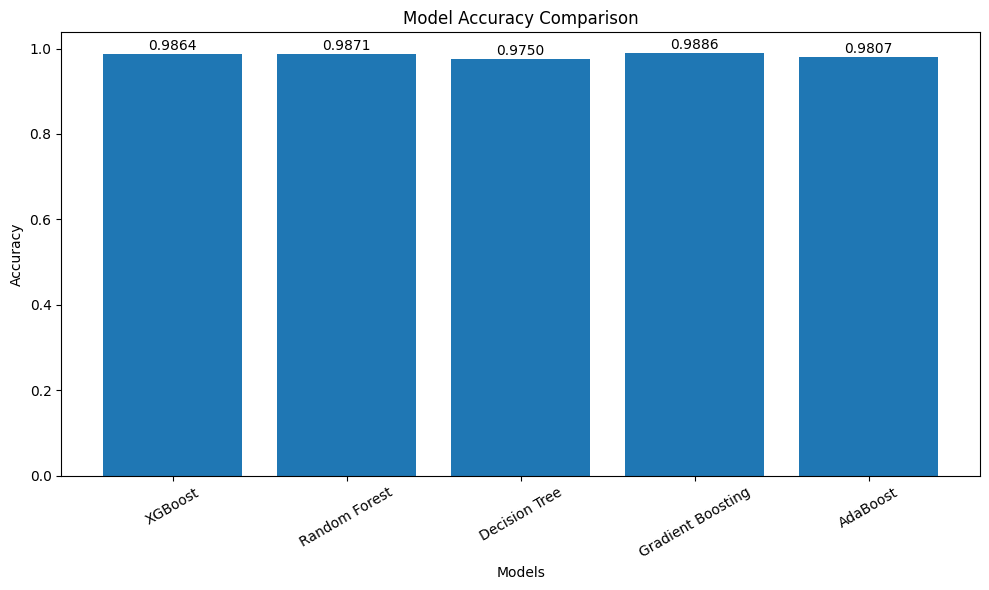

In [25]:
accuracy = {
    'XGBoost': xgb_accuracy,
    'Random Forest': rf_accuracy,
    'Decision Tree': dt_accuracy,
    'Gradient Boosting': gb_accuracy,
    'AdaBoost': ab_accuracy
}

plt.figure(figsize=(10,6))
plt.bar(accuracy.keys(), accuracy.values())
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=30)
for i, v in enumerate(accuracy.values()):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()

In [26]:
best_model = max(accuracy, key=accuracy.get)

if len(set(accuracy.values())) == 1:
    print("All models have same accuracy → possible data leakage.")
else:
    print(f"Best model: {best_model} with accuracy {accuracy[best_model]:.4f}")

Best model: Gradient Boosting with accuracy 0.9886


In [31]:
import joblib

joblib.dump({
    'model': model_gb,
    'encoder': le,
}, 'burnout.pkl')

['burnout.pkl']